# xlsx reading test

In [1]:
import openpyxl
import pandas as pd
# Read data from Excel file
df = pd.read_excel('H:\\Document\\lab\\data 20240423\\A1AT&APOA2\\OC_A1AT&ApoA2_給東皓\\OC_reanalysis.xlsx', sheet_name='A1AT_eSUM')
print(df.columns)
# Define the subset
subset = ['disease', 'B/A']

# Drop NaN values in the specified subset
df = df.dropna(subset=subset)

# Get the values
y_true = df[subset[0]].values
y_scores = df[subset[1]].values

print(y_true)
print(y_scores)

FileNotFoundError: [Errno 2] No such file or directory: 'H:\\Document\\lab\\data 20240423\\A1AT&APOA2\\OC_A1AT&ApoA2_給東皓\\OC_reanalysis.xlsx'

# ROC

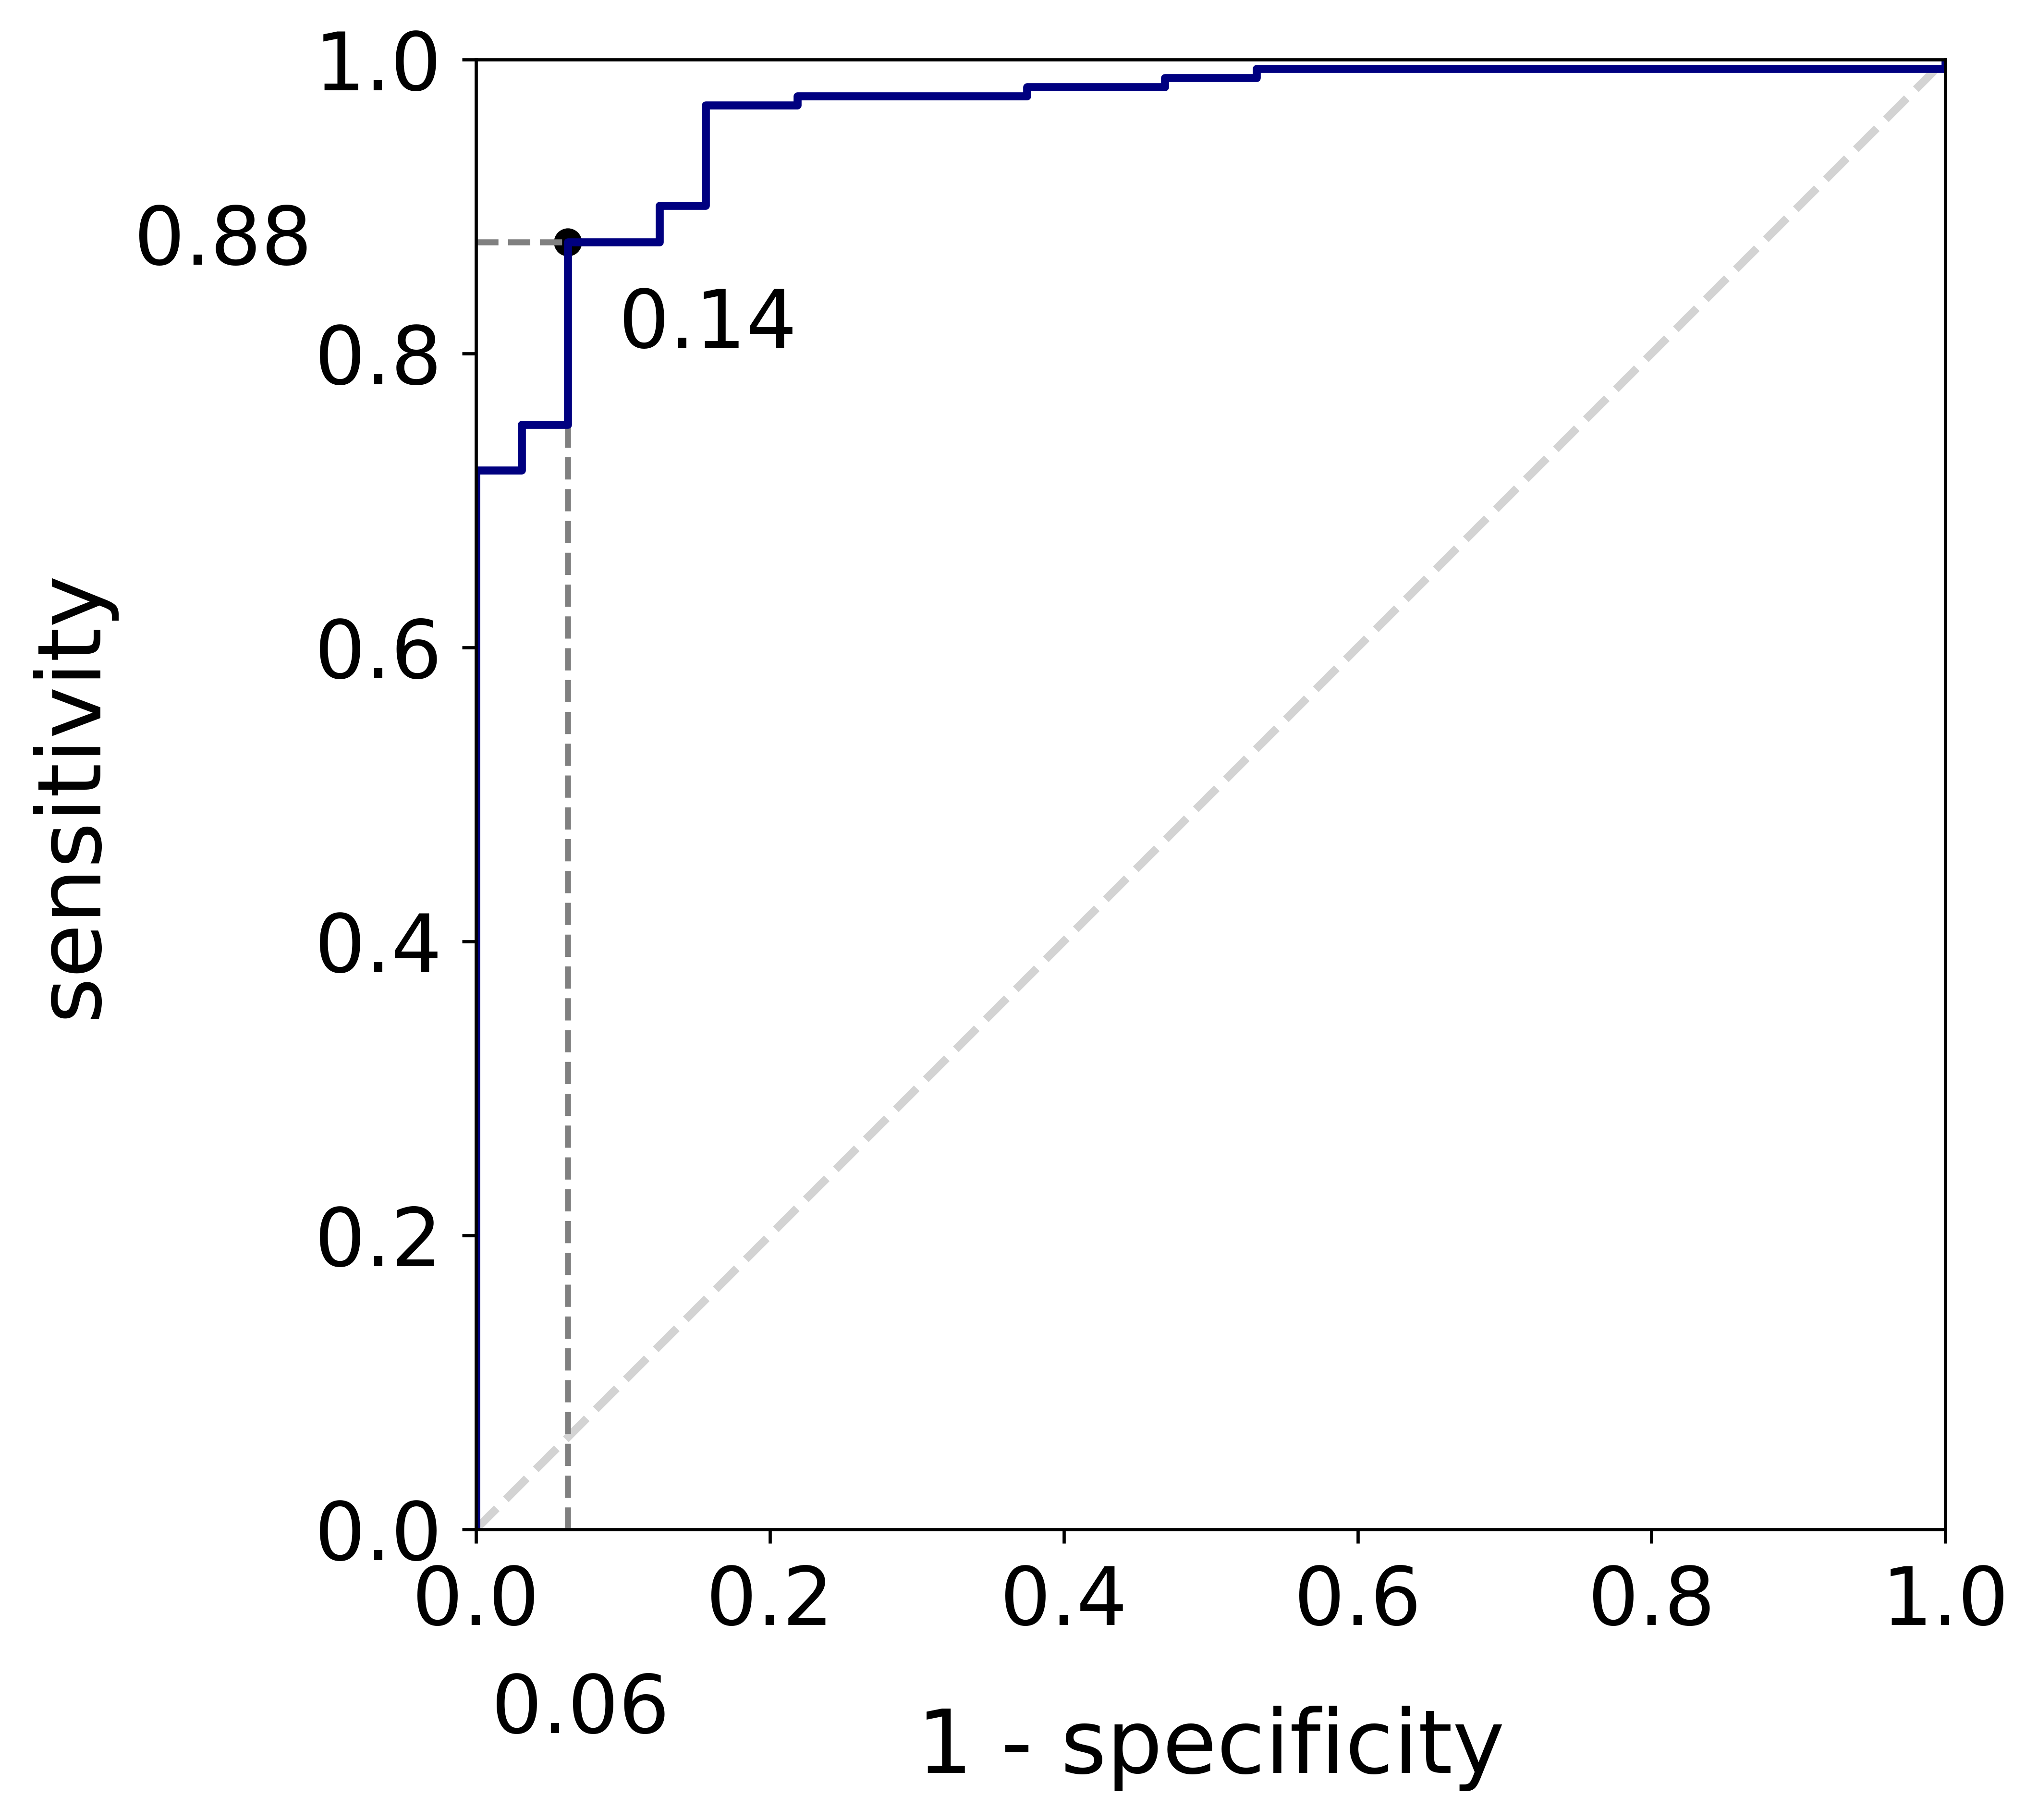

In [9]:
import pandas as pd
import openpyxl
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# 0--> Youden's index, 1--> Euclidean distance, 2--> distance from y=x, 3--> custom
cutoff_method = 1
# 0--> both, 1--> only x, 2--> only y, 3--> no
axis_style = 0
# Read data from Excel file
df = pd.read_excel(r'C:\tmp_space\ApoA2_A1AT_manuscript\BC_APOA2_redo.xlsm', sheet_name='20250702SUM')

# Define the subset
subset = ['disease', 'D/B']

def set_size(w,h, ax=None):
    """ w, h: width, height in inches """
    if not ax: ax=plt.gca()
    l = ax.figure.subplotpars.left
    r = ax.figure.subplotpars.right
    t = ax.figure.subplotpars.top
    b = ax.figure.subplotpars.bottom
    figw = float(w)/(r-l)
    figh = float(h)/(t-b)
    ax.figure.set_size_inches(figw, figh)

def plot_roc_curve(y_true, y_scores):
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)

    youden_index = tpr - fpr
    euclidean_distance = np.sqrt((tpr - 1)**2 + (fpr-0)**2)
    if cutoff_method == 0:
        optimal_idx = np.argmax(youden_index)
    elif cutoff_method == 1:
        optimal_idx = np.argmin(euclidean_distance)
        # find second
        # euclidean_distance[optimal_idx] = np.inf
        # optimal_idx = np.argmin(euclidean_distance)
        
    elif cutoff_method == 2:
        distances = np.abs(fpr - tpr)
        optimal_idx = np.argmax(distances)
        # find second
        # distances[optimal_idx] = -np.inf
        # optimal_idx = np.argmax(distances)
        
    else:
        youden_index = 1.5*tpr - fpr
        optimal_idx = np.argmax(youden_index)
    optimal_threshold = thresholds[optimal_idx]
    optimal_tpr = tpr[optimal_idx]
    optimal_fpr = fpr[optimal_idx]
    
    fig, ax = plt.subplots(figsize=(10, 10), dpi=600)  # Make the figure square
    set_size(5.1,5.1, ax) # The first and second value need to be same to make the figure square
    plt.plot([0, 1], [0, 1], color='lightgray', lw=2, linestyle='--')
    plt.plot([optimal_fpr, optimal_fpr], [0, optimal_tpr], '--', color='gray')  # Add a vertical dotted line
    plt.plot([0, optimal_fpr], [optimal_tpr, optimal_tpr], '--', color='gray')  # Add a horizontal dotted line
    # Add texts to indicate the optimal TPR and FPR
    # optimal threshold text
    plt.text(optimal_fpr, optimal_tpr - 0.03, f'  {optimal_threshold:.2f}', 
             horizontalalignment='left', verticalalignment='top', fontsize=20)  
    plt.plot(fpr, tpr, color='navy', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.scatter(optimal_fpr, optimal_tpr, color='black')  # Add a dot for the optimal point
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.0])
    # plt.xlabel('1 - specificity')
    # plt.ylabel('sensitivity')
    # plt.title('Receiver Operating Characteristic')
    # plt.legend(loc="lower right")
    plt.tick_params(axis='both', which='major', labelsize=20, pad=5)  # Increase ticks font size
    # Set the labelcolor to white to hide tick labels

    if axis_style ==0:
        plt.tick_params(axis='x', labelcolor='black', color='black')
        plt.tick_params(axis='y', labelcolor='black', color='black')
        # ~
        plt.text(-0.25, optimal_tpr, f' {optimal_tpr:.2f}', fontsize=20, horizontalalignment='left', verticalalignment='center')
        plt.text(optimal_fpr, -0.15, f' {optimal_fpr:.2f}', fontsize=20, horizontalalignment='center', verticalalignment='bottom')
    elif axis_style ==1:
        plt.tick_params(axis='x', labelcolor='black', color='black')
        plt.tick_params(axis='y', labelcolor='white', color='black')
        # ~
        plt.text(-0.2, optimal_tpr, f' {optimal_tpr:.2f}', fontsize=20, horizontalalignment='left', verticalalignment='center')
        plt.text(optimal_fpr, -0.15, f' {optimal_fpr:.2f}', fontsize=20, horizontalalignment='center', verticalalignment='bottom')
    elif axis_style ==2:
        plt.tick_params(axis='x', labelcolor='white', color='black')
        plt.tick_params(axis='y', labelcolor='black', color='black')
        # ~
        plt.text(-0.31, optimal_tpr, f' {optimal_tpr:.2f}', fontsize=20, horizontalalignment='left', verticalalignment='center')
        plt.text(optimal_fpr, -0.15, f' {optimal_fpr:.2f}', fontsize=20, horizontalalignment='center', verticalalignment='bottom')
    elif axis_style ==3:
        plt.tick_params(axis='x', labelcolor='white', color='black')
        plt.tick_params(axis='y', labelcolor='white', color='black')
        # ~
        plt.text(-0.2, optimal_tpr, f' {optimal_tpr:.2f}', fontsize=20, horizontalalignment='left', verticalalignment='center')
        plt.text(optimal_fpr, -0.15, f' {optimal_fpr:.2f}', fontsize=20, horizontalalignment='center', verticalalignment='bottom')

    plt.xlabel("1 - specificity", fontsize=22, labelpad=16)
    plt.ylabel("sensitivity", fontsize=22, labelpad=50)

    plt.savefig(r'C:\tmp_space\ApoA2_A1AT_manuscript\figure output\roc_curve.png', dpi=600, bbox_inches='tight', pad_inches=0, facecolor='white', edgecolor='none')
    plt.show()

# Drop NaN values in the specified subset
df = df.dropna(subset=subset)
# Get the values
y_true = df[subset[0]].values
y_scores = df[subset[1]].values

# Call the function with your data
plot_roc_curve(y_true, y_scores)

# Box plot

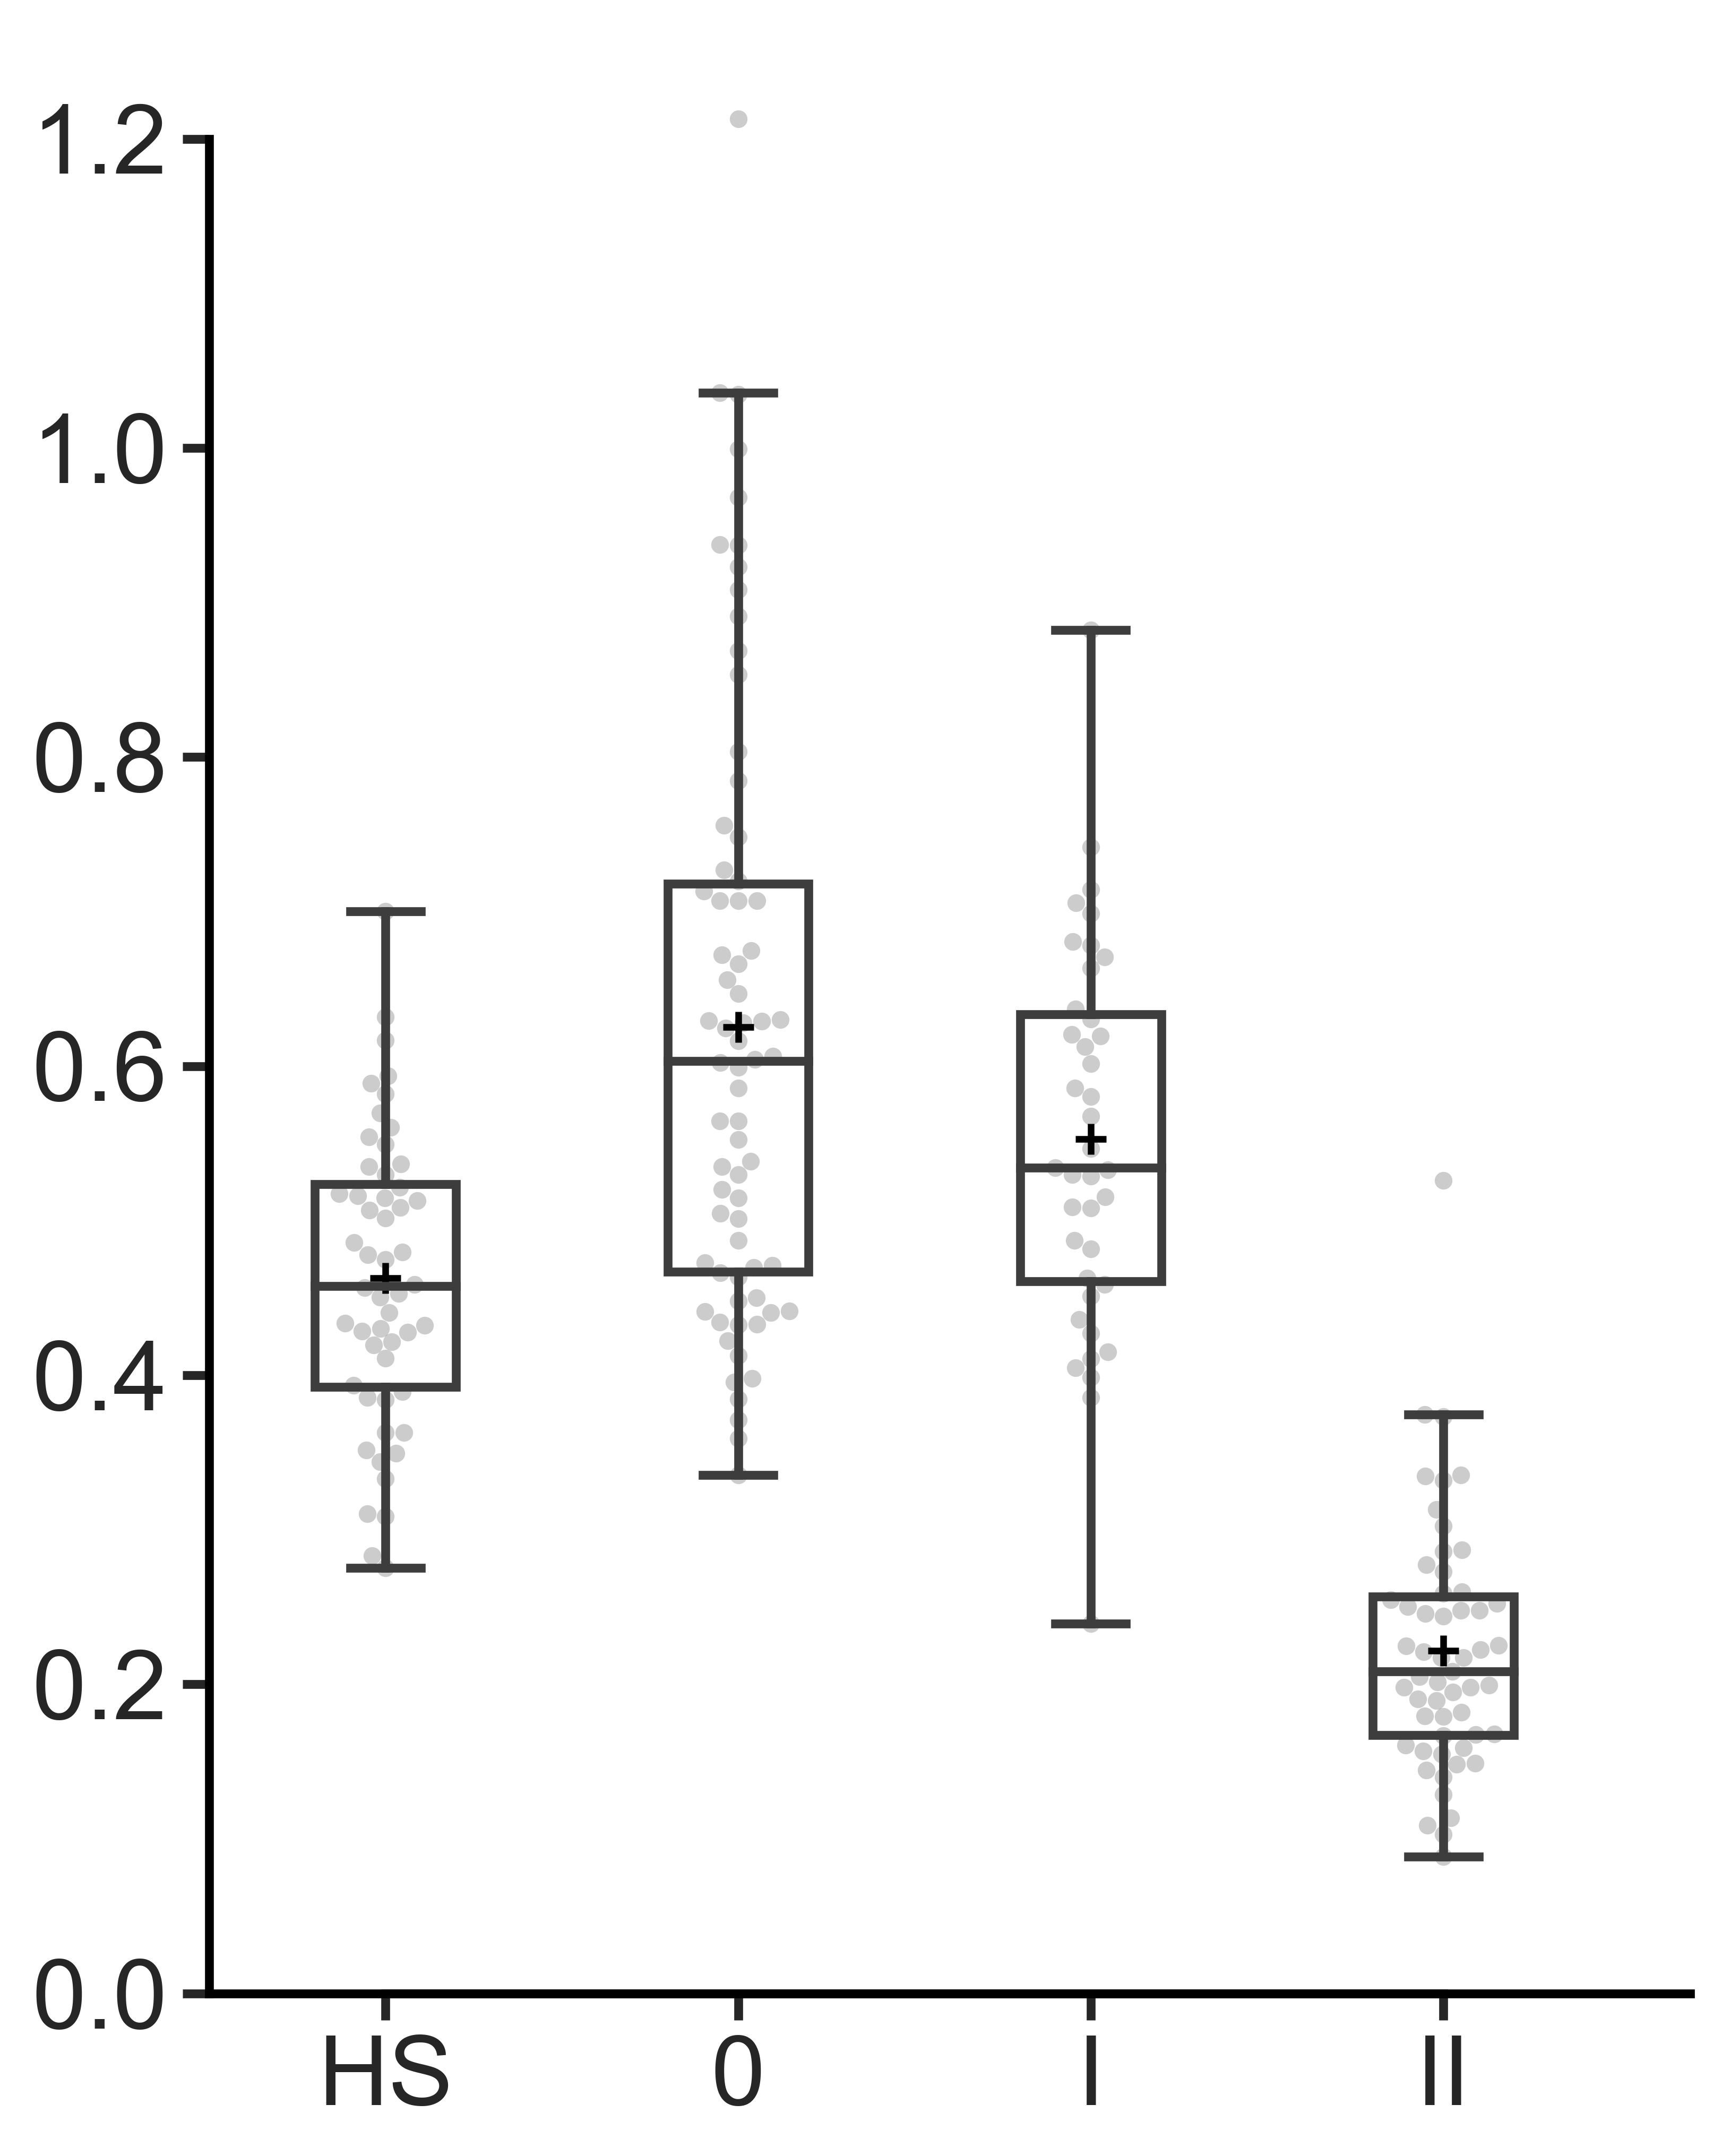

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = r'C:\tmp_space\BC_APOA2_redo.xlsm'
sheet = 'SUM (2)'
# Specify the columns to read###################################################################################
column_num = 4
# column names in xlsx file###################################################################################
columns = ['h(D+F)/B', '0(D+F)/B', '1(D+F)/B', '2(D+F)/B']
df = pd.read_excel(file_path, sheet_name=sheet, usecols=columns)
# labels you want to put on figure###################################################################################
df.columns = ['HS', '0', 'I', 'II']
sns.set_style('ticks')
if column_num == 2:
    plt.figure(figsize=(5, 7.5), dpi=600)
elif column_num == 4:
    plt.figure(figsize=(6, 8), dpi=600)
elif column_num == 5:
    plt.figure(figsize=(7, 7), dpi=600)
elif column_num == 6:
    plt.figure(figsize=(8, 8), dpi=600)

# Overlay the semi-transparent data points with jitter
sns.swarmplot(data=df, color='black', alpha=0.2, size=4, zorder=.5, orient='v')

# Create the boxplot
boxplot = sns.boxplot(data=df, width=0.4, linewidth=2, boxprops=dict(facecolor='none'), color='black', showfliers=False)

# Customize the boxplot to have squared termini for the min and max fences
for line in boxplot.get_lines():
    line.set_solid_capstyle('projecting')

# Calculate and plot the mean for each group
means = df.mean()
for i, mean in enumerate(means):
    plt.scatter(i, mean, color='black', s=50, marker='+', zorder=2)

# Set the tick parameters with fontsize###############################################################################
if column_num == 2:
    plt.xticks(ticks=[0, 1], labels=df.columns, fontsize=22, rotation=45, ha='center')
    # Adjust the plot limits to set the distance to the border
    plt.xlim(-0.5, 0.5*len(df.columns) + 0.5)
elif column_num == 4:
    plt.xticks(ticks=[0, 1, 2, 3], labels=df.columns, fontsize=22, rotation=0, ha='center')
    plt.xlim(-0.5, 0.8*len(df.columns) + 0.5)
elif column_num == 5:
    plt.xticks(ticks=[0, 1, 2, 3, 4], labels=df.columns, fontsize=22, rotation=45, ha='center')
    plt.xlim(-0.5, 0.8*len(df.columns) + 0.5)
elif column_num == 6:
    plt.xticks(ticks=[0, 1, 2, 3, 4, 5], labels=df.columns, fontsize=22, rotation=45, ha='center')
    plt.xlim(-0.5, 0.85*len(df.columns) + 0.5)

plt.yticks(fontsize=22)
plt.ylim(0, None)

# Only draw the x and y axes (left and bottom spines) in black
sns.despine(trim=True, left=False, bottom=False)
ax = plt.gca()
ax.spines['left'].set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_linewidth(2)  # Match the boxplot linewidth
ax.spines['bottom'].set_linewidth(2)  # Match the boxplot linewidth

# Set the width of the y-axis and x-axis ticks
ax.tick_params(axis='y', width=2, length=6)  # Adjust tick width and length for y-axis
ax.tick_params(axis='x', width=2, length=6)  # Adjust tick width and length for x-axis

# Hide the top and right spines completely
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Draw a horizontal line at y=0 with squared termini
line = plt.axhline(0, color='black', linewidth=2, clip_on=False)
line.set_solid_capstyle('projecting')

# Show the plot
plt.show()
